# Single Spin ESR Tutorial

This tutorial demonstrates how to simulate electron spin resonance (ESR) of a single quantum dot using PyESRSTM. We will learn how to:

1. Set up a quantum dot system with spin and magnetic field
2. Define metal electrodes and their properties
3. Calculate electron hopping rates between the dot and electrodes
4. Solve the master equation to obtain the density matrix
5. Compute ESR signals and verify convergence
6. Fit the ESR data to extract physical parameters

## Setup and Imports

We start by importing the necessary libraries.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from time import time

import sys
sys.path.append('..')
from PyESRSTM import  units



## Quantum Dot

The quantum dot is the central object in our simulation. It represents a small region where you can trap electrons and spins. The `QD` object encapsulates all information about:

- **Single electron energy** ($\epsilon$): The energy to add one electron to the empty dot
- **Interaction energy** ($U$): The Coulomb repulsion when adding a second electron
- **Spin configuration**: The spin quantum numbers and their orientations
- **Magnetic field**: The external field that creates the Zeeman splitting
- **g-factor**: How strongly the spin couples to the magnetic field

Additional parameters will added in next tutorials.

The `QD` class solves the Hamiltonian from Ref [^Galvez2021] using Quspin [^quspin] to compute energy levels and spin states of the system.

### Creating a Quantum Dot

Below we create a single-spin quantum dot with:
- $\epsilon = -30$ meV
- $U = 100$ meV  
- single spin 1/2 - we will consider more complex systems in a future tutorial. 
- Magnetic field with magnitude ~0.6 T, oriented primarily in the z-direction
- g-factor of 2.0 (typical for electrons)

In [9]:
from PyESRSTM import QD
#    eps[meV],U[meV],       spins,                                  Magnetic field[T],        Gyromagnetic factor
dot = QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))
print(dot)

Hermiticity check passed!
idx 	Occup 	Energy [meV] 	Spin central 	Spin total
				 x,  y,  z 	 x,  y,  z
0	1 	-30.035209352 	-0.2 -0.0 -0.5 	-0.2 -0.0 -0.5
1	1 	-29.964790648 	0.2 0.0 0.5 	0.2 0.0 0.5
2	0 	0.000000000 	0.0 0.0 0.0 	0.0 0.0 0.0
3	2 	40.000000000 	0.0 0.0 0.0 	0.0 0.0 0.0


### Inspecting Quantum Dot Properties

Now let's examine the key properties of the quantum dot we just created. These include the number of states (energy levels) generated by the Hamiltonian, the energy spacings (crucial for resonance conditions), and the spin expectation values $\langle S_x, S_y, S_z \rangle$ in each eigenstate.

In [10]:
print('Number of spins:',dot.Nspin)
print('Number of states:',dot.Nstate)
print('Occupancy:',dot.Occupancy)
print('Energies [meV]:', np.round(dot.Energies*units.Hartree,3))
print('Theta [deg]: ', np.round(dot.theta/np.pi*180, 3))
print()

print('Lambda:')
print('i,\tj,\tsigma,\tlambda')
print(dot.print_lamb())
print()

print('Spins states')
print('state, spin site,  <Sx>, <Sy>,  <Sz>')
print(np.round(dot.CalcAllSpin(),3))


Number of spins: 1
Number of states: 4
Occupancy: [1 1 0 2]
Energies [meV]: [-30.035 -29.965   0.     40.   ]
Theta [deg]:  20.0

Lambda:
i,	j,	sigma,	lambda
0	3	0	-0.98481 + i0.00000
0	3	1	0.17365 + i0.00000
1	3	0	-0.17365 + i0.00000
1	3	1	-0.98481 + i0.00000
2	0	0	0.17365 + i0.00000
2	0	1	-0.98481 + i0.00000
2	1	0	-0.98481 + i0.00000
2	1	1	-0.17365 + i0.00000


Spins states
state, spin site,  <Sx>, <Sy>,  <Sz>
[[[ 1.     1.    -0.171 -0.    -0.47 ]]

 [[ 2.     1.     0.171  0.     0.47 ]]

 [[ 3.     1.     0.     0.     0.   ]]

 [[ 4.     1.     0.     0.     0.   ]]]


/home/matyas/Programs/PyESRSTM/Tutorial/../PyESRSTM/QD/QD.py:338: ComplexWarning: Casting complex values to real discards the imaginary part
  string += '{:.0f}\t{:.0f}\t{:.0f}\t{:.5f} + i{:.5f}\n'.format(*state[:3].astype(int), np.real(state[3]), np.imag(state[3]))


## Electrodes

Electrons tunnel between the quantum dot and metal electrodes. The `Electrode` object characterizes each electrode by:

- **DC voltage** ($V_{DC}$): A constant potential that shifts the electrode's Fermi level relative to the dot
- **RF voltage** ($V_{RF}$): An oscillating voltage at radio frequency (applied when studying driven systems)
- **Coupling strength**: How strongly the electrode couples to the dot (affects tunneling rates)
- **Broadening**: The energy width of the dot's orbital levels in the electrode (impacts tunneling)
- **Temperature**: The electron temperature of the electrode (affects Fermi-Dirac distribution)

The `Electrode` object pre-computes:
- A grid of energy points needed to evaluate the Fermi integral
- The Fermi-Dirac distribution at each grid point
- Density of states (DOS) - can be customized for different materials

This pre-computation speeds up rate calculations, since we'll reuse these grids for different quantum dot configurations.

DOS= 1 , In this case very boring, but could be a function


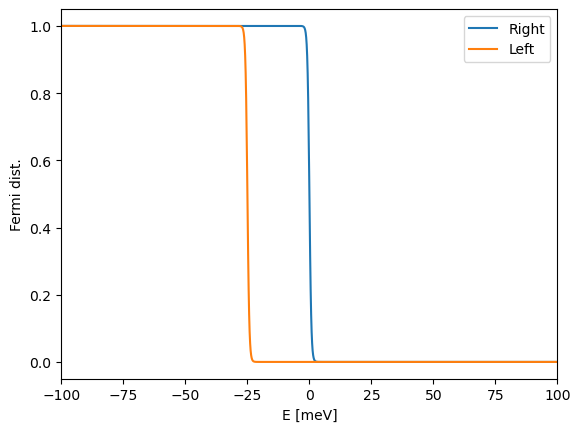

In [11]:
from PyESRSTM import Electrode
#               Vdc, VRF, P,  coupling, broadening  Temperature,
Right = Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)

fermiR = Right.fermi
enerR = Right.grid
dos = Right.dos(enerR)
print('DOS=', dos, ', In this case very boring, but could be a function')

fermiL = Left.fermi
enerL = Left.grid

plt.plot(enerR*units.Hartree, fermiR, label='Right')
plt.plot(enerL*units.Hartree, fermiL, label='Left')
plt.xlabel('E [meV]')
plt.ylabel('Fermi dist.')

plt.xlim(-100, 100)
plt.legend()
plt.show()



### Visualizing the Fermi Window

Below we create two electrodes with different DC biases and plot their Fermi distributions. This illustrates how the DC voltage shifts the "Fermi window"—the range of energies from which electrons can tunnel into the dot. The electrodes' Fermi levels must overlap with the dot's energy levels to allow current flow.

### Alternative Driving Method: A-drive

Instead of voltage-driven RF, you can also drive the coupling constant itself (important in some experimental setups). The optional parameter `Adrive` specifies the amplitude of coupling modulation.

In [12]:
Adriven = Electrode(-25, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000, Adrive=.5)

## Hopping Rates Between Electrodes and Quantum Dot

The `rates()` function calculates the electron tunneling rates $\Gamma$ from the quantum dot to each electrode. These rates depend on:

- The dot's orbital levels and spin states
- The electrode's Fermi level and density of states  
- The tunneling coupling strength

It can be expressed as [^Galvez2021,^Nachtigall2026]
$$ \Gamma_{vl,ju;n} = \sum_{\alpha} \Gamma_{vl,ju,\alpha;n}^+ + \Gamma_{vl,ju,\alpha;n}^- $$
$$\Gamma_{vl,ju,\alpha;n}^+=  \sum_{\sigma}  \gamma^0_{\alpha\sigma} \lambda_{vl\sigma} \lambda^*_{uj\sigma} \sum_{m}  I_{\alpha}^{+}\left(\Delta_{ju} - m\hbar\omega\right) J_{m}\left(\frac{eV_{\alpha}^{RF}}{\hbar\omega}\right) J_{m-n} \left(\frac{eV_{\alpha}^{RF}}{\hbar\omega}\right) $$
$$\Gamma_{vl,ju, \alpha;n}^- = \sum_{\sigma} \gamma^0_{\alpha\sigma} \lambda^*_{lv\sigma} \lambda_{ju\sigma} \sum_{m} I_{\alpha}^{-}\left(\Delta_{ju} + m\hbar\omega\right) J_{m+n}\left(\frac{eV_{\alpha}^{RF}}{\hbar\omega}\right) J_{m} \left(\frac{eV_{\alpha}^{RF}}{\hbar\omega}\right)$$
$$ I_{\alpha}^{\pm}\left(\Delta_{ij}\right)
    = \frac{i}{2\pi} 
    \int_{-E_{cut}}^{E_{cut}}  \frac{f^{\pm}_\alpha\left(\varepsilon\right)}
    {\pm \varepsilon - \Delta_{ij} + \frac{i\hbar}{\tau_C}}  d \varepsilon
$$
where $\alpha$ describes the electrode, and $u$,$v$,$j$,$l$ are QD energy levels.





In [13]:
from PyESRSTM import rates, sum_rates
# The surface is static so we only look at the static component 0 Fourier components 
# The frequency is thus arbitrary and we set it to zero. 
#                      QD, Electrode, freq, NFC         
GRplus, GRminus = rates(dot,     Right, 0,   0)

# The tip is oscilating, we thus we want to keep the hi
GLplus, GLminus = rates(dot,      Left, 20,   5)

print(GRplus.shape, GLplus.shape)

(4, 4, 4, 4, 1) (4, 4, 4, 4, 11)


### Calculating Tunneling Rates

Now we calculate the electron hopping rates between the quantum dot and each electrode. The key differences:

- **Right electrode**: Static (no driving), so only a `0`-th Fourier component (DC rates)
- **Left electrode**: Oscillating RF field at 20 GHz, so we keep 5 Fourier components to accurately capture the time-varying rates

The rates are 4D tensors with indices: (QD_state, QD_state, QD_state, QD_state, Fourier component)

Since the rates have different shapes we need to be careful summing. For convinience there is a function `sum_rates()` that takes care of the difference in shape.

In [14]:
# this is safe as they are the same shape
GL = GLminus + GLplus 
GR = GRminus + GRplus

# This is wrong, but wont give an error in this case
# The constant component of GR is projected into all 5 Fourier components 
G_naive = GL + GR

# This is correct
G_correct = GL.copy()
G_correct[:,:,:,:,5] += GR[:,:,:,:,0]

# This is also correct but unecesery
# by increasing the nomber of Floquet componets we essentially pad the surface rates with zeros
GRplus_large, GRminus_large = rates(dot,     Right, 0,   5)
GR_large = GRminus_large + GRplus_large
G_brute = GL + GR_large

# This is easier and more general 
G = sum_rates(GL, GR)


print(np.all(G == G_naive), np.all(G == G_correct), np.all(G==G_brute))

False True True


### Master Equation

From the hopping rates, we can now solve the **master equation** to find the steady-state density matrix $\rho$ of the system. The master equation describes how the occupation probability of each quantum state evolves:

$$
    \left(n\hbar\omega+ \Delta_{lj}\right) \rho_{lj;n}
    = i \sum_{vu;m} \big[\Gamma_{vl,ju;m}\rho_{vu;n-m} - \Gamma^{*}_{lv,vu;-m}\rho_{uj;n-m}
    -   \Gamma_{jv,vu;m}\rho_{lu;n-m} + \Gamma^*_{vj,lu;-m}\rho_{uv;n-m} \big ] 
$$

The density matrix encodes all information about which states are occupied at steady state.

In [15]:
from PyESRSTM import QME

rho = QME(G, 20., Delta=dot.Delta)
print(rho.shape)

(4, 4, 11)


### Optimization: Pre-computing the Master Equation Matrix

For single-frequency ESR scans, we often need to solve the master equation at many frequencies but with the same hopping rates. Re-solving the full system at each frequency is redundant—much of the matrix structure is already built.

The `QME_matrix()` function pre-computes the frequency-independent part as a sparse matrix. We then pass this to `QME()` with the flag `qme_matrix=True` to quickly solve for each new frequency. This can speed up a frequency scan by $\sim$2-3×.

In [16]:
from PyESRSTM import QME_matrix

M = QME_matrix(G, dot.Delta)
rho = QME(M, 20, qme_matrix=True)

### Current

The measurable quantity in an experiment is the current flowing through the tip electrode (left electrode). This is calculated from the current-generating rates $\Gamma^{+} - \Gamma^{-}$ (which differs from $\Gamma^{+} + \Gamma^{-}$ used for population dynamics) and the density matrix:

$$I_n = \frac{e}{\hbar} \sum_{lju;m} \rho_{lu;-n-m}\Gamma^C_{ljju,L;m} + \rho^*_{lu;n-m}\Gamma^{C*}_{ljju,L;m}$$

For a driven system with $2N_{FC}+1$ Fourier components, the current has multiple components corresponding to different harmonic frequencies. The DC (zero-frequency) component is the steady-state current.

In [17]:
from PyESRSTM import current

GC = GLplus - GLminus
I = current(rho, GC)

print(f'DC current: {I[5]:.2f}')

DC current: -2.03+0.00j


### Spin Dynamics Descriptors

Before computing full ESR spectra, we can extract important spin-dynamics information directly from the rates. These are simplified physical parameters that characterize the spin behavior:

- **Lamb shift** ($B_{exc;0}$): A frequency shift of the spin due to the exchange interaction with electrons in the electrodes
- **Exchange driving** ($B_{exc;1}$): The amplitude of RF-induced driving of the exchange interaction  
- **Spin-transfer torque (STT)** ($\langle S_z \rangle_{acc}$): How the electron flow exerts a torque on the spin
- **Relaxation time** ($T_1$): How quickly the spin loses coherence due to electron tunneling

**Warning**: These descriptors are only valid for single-spin systems with simple geometries.

In [18]:
from PyESRSTM.postproces.dynamics import Bexch, Trel, Szacc

Lamb = Bexch(G, dot.theta)*units.Hartree/units.GHz
Bdrive = Bexch(G, dot.theta, n=1)*units.Hartree/units.GHz
T1 = Trel(G)*units.Hartree/units.GHz
Sz0 = Szacc(G, rho, dot.theta)*units.Hartree/units.GHz
Sz1 = Szacc(G, rho, dot.theta, n=1)*units.Hartree/units.GHz

print(f'Lamb shift: {Lamb:.4f} GHz')
print(f'Exchange Driving: {Bdrive:.4f} GHz')
print(f'STT static: {Sz0:.4f} GHz')
print(f'STT driving: {Sz1:.4f} GHz')
print(f'T1: {T1:.4f} GHz (maybe this is T2)')

Lamb shift: 0.0762 GHz
Exchange Driving: -0.0133 GHz
STT static: -0.0007 GHz
STT driving: 0.0007 GHz
T1: 0.0041 GHz (maybe this is T2)


## ESR Signal

To obtain the full electron spin resonance spectrum, we scan the driving frequency over a range and compute the current at each frequency. The ESR signal shows resonance peaks when the driving frequency matches a spin transition in the quantum dot.

**Physical meaning**: The RF field at the tip electrode can induce spin-flip transitions when the frequency is resonant. This changes the dot's occupancy and thus the current—creating an ESR "signal" that we can measure.

The `ESR.ESR()` function automates this frequency scan by:
1. Setting the frequency for the left (oscillating) electrode
2. Computing rates for this frequency
3. Solving the master equation
4. Extracting the DC current component
5. Returning the current at all harmonic frequencies

Only the resonant frequency components show strong signals; off-resonance frequencies give a small background.

/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


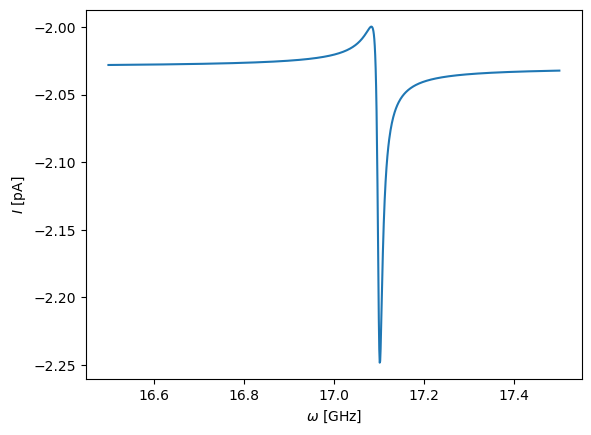

In [19]:
from PyESRSTM import ESR

freq = np.linspace(16.5, 17.5, 1000)
I = ESR.ESR(Left, Right, dot, freq, NFL=5)
# the returned signal is in the shape (len(freq), 2*NFL+1)

plt.plot(freq, I[:, 5])
plt.xlabel(r'$\omega$ [GHz]')
plt.ylabel(r'$I$ [pA]')
plt.show()

### Convergence with Number of Integration Points

To compute tunneling rates, we must evaluate integrals involving the Fermi-Dirac distribution and density of states. The number of grid points used for numerical integration (`Nint`) directly affects accuracy and computation time.

**The problem**: With naive uniform sampling, the Fermi integral changes most near the Fermi level and the dot's energy levels. Away from these regions, the integrand is nearly constant, so uniform sampling wastes points.

**The solution** shown below: Use adaptive sampling with locally-refined "segments" around the important energies ($\epsilon$ and $\epsilon + U$). This gives much faster convergence with fewer total points.

Nint=1000: 0.91 s
Nint=3000: 1.03 s
Nint=10000: 1.60 s
Nint=30000: 3.50 s
Nint=100000: 8.91 s


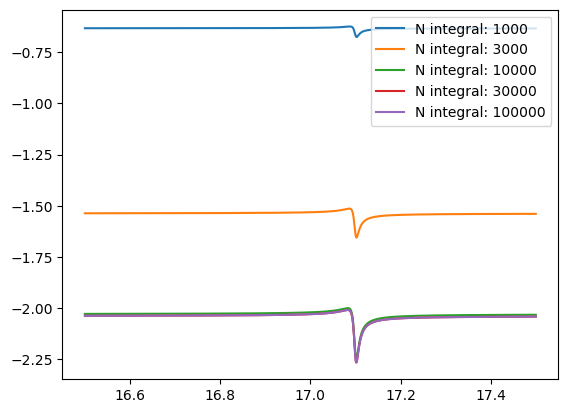

In [20]:
Nint = [1e3, 3e3, 1e4, 3e4, 1e5]

freq = np.linspace(16.5, 17.5, 1000)

NF = 2

for N in Nint:
    ts = time()
    Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=N, Cutoff=1000)
    Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=N, Cutoff=1000)

    I= ESR.ESR(Left, Right, dot, freq, NFL=NF)
    plt.plot(freq, I[:, NF], label=f'N integral: {int(N)}')

    tf = time()
    print(f'Nint={int(N):d}: {tf-ts:.2f} s')

plt.legend()
plt.show()

### Efficient Integration with Adaptive Segments

However the above is inefficient: the integrand is nearly constant everywhere **except near the QD energy levels**. Rather than sample uniformly, we place higher-density sampling grids ("segments") at the important regions.

Below we add two segments of width 60 meV centered on the dot's single-electron and two-electron energy levels ($\epsilon$ and $\epsilon + U$). This dramatically improves convergence!

Nint=1000: 0.80 s
Nint=3000: 0.96 s
Nint=10000: 2.02 s
Nint=30000: 4.02 s
Nint=100000: 8.90 s


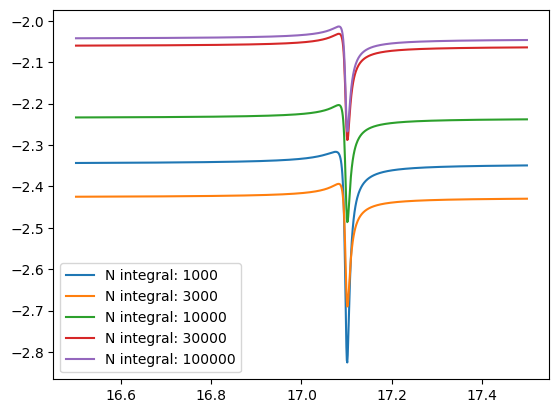

In [21]:
Nint = [1e3/3, 3e3/3, 1e4/3, 3e4/3, 1e5/3]

freq = np.linspace(16.5, 17.5, 1000)
freq = np.sort(freq)
NF = 2

for N in Nint:
    ts = time()
    Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=N, Cutoff=1000,
                      segments=[[dot.eps,30, int(N)],[dot.U+dot.eps,30,int(N)] ])
    Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=N, Cutoff=1000,
                     segments=[[dot.eps,30, int(N)],[dot.U+dot.eps,30,int(N)] ])

    I= ESR.ESR(Left, Right, dot, freq, NFL=NF)
    plt.plot(freq, I[:, NF], label=f'N integral: {int(3*N)}')

    tf = time()
    print(f'Nint={int(3*N):d}: {tf-ts:.2f} s')

plt.legend()
plt.show()

### Convergence with Fourier Components

When the tip electrode has an RF drive at frequency $\omega$, we expand all quantities (rates, density matrix, current) in a Fourier series with $2N_F + 1$ components (frequencies: $-N_F\omega, \ldots, 0, \ldots, +N_F\omega$).

**Key insight**: A resonance feature requires Fourier components up to a certain minimum number, determined by the highest harmonics generated. Once we have enough components to capture the physics, adding more doesn't change the result—it just wastes computation.

This section sweeps over the number of Fourier components to show:
- How the ESR resonance peak changes with more components
- The point at which adding more components gives no improvement
- The computational cost (time) for each choice

**Visualization note**: Each curve is slightly offset in frequency for clarity since they would otherwise overlap.

Hermiticity check passed!
NF=1: 10.53 s
NF=2: 10.26 s
NF=3: 12.82 s
NF=4: 14.02 s


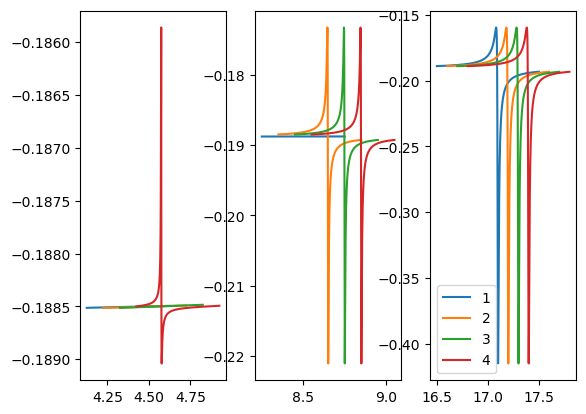

In [22]:
dot_norm = QD(-30, 100, np.array([0.5]), np.array([[2.0804273,  0.00000000,  5.7159271]]), np.array([[2.0, 2.0, 2.0]]))

NFs = [1,2,3,4]
Nint = 3e3
df = 0
Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30, Nint]])
Left = Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])

freq1 = np.linspace(4.125, 4.625, 500)
freq2 = np.linspace(8.25, 8.75, 500)
freq3 = np.linspace(16.5, 17.5, 500)

fig, ax = plt.subplots(1,3)

for NF in NFs:
    ts = time()

    I = ESR.ESR(Left, Right, dot, freq1, NFL=NF)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq1, NFL=NF)
    ax[0].plot(freq1+df, (I-I_norm)[:, NF], label=f'{NF}')
    
    I = ESR.ESR(Left, Right, dot, freq2, NFL=NF)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq2, NFL=NF)
    ax[1].plot(freq2+df, (I-I_norm)[:, NF], label=f'{NF}')
    
    I = ESR.ESR(Left, Right, dot, freq3, NFL=NF)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq3, NFL=NF)
    ax[2].plot(freq3+df, (I-I_norm)[:, NF], label=f'{NF}')

    tf = time()
    print(f'NF={NF:d}: {tf-ts:.2f} s')
    df += .1

plt.legend()
plt.show()

## Fitting ESR Spectra to Extract Parameters

So far, we've computed ESR spectra from known system parameters. In experiments, we measure ESR signals but don't know the physical parameters exactly. This section shows how to fit measured spectra to extract information about:

- **Larmor frequency** ($\omega_0$): The spin precession frequency (dominant term)
- **Linewidth** ($\gamma$): How broad the resonance is (related to $T_2$, dephasing time)  
- **Asymmetric and symmetric current components** ($I_a, I_s$): Different physical mechanisms generating current

The `ESR_fit_fun()` provides a resonance line shape (typically Lorentzian) for fitting. We use `guess_p0()` to get initial parameter estimates, which is essential for robust fitting.

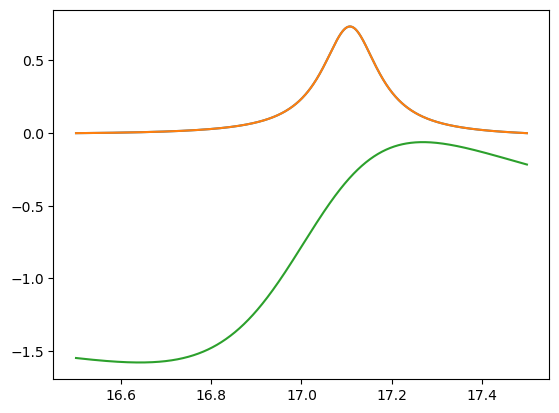

In [23]:
from scipy.optimize import curve_fit

Nint = 1e4
NF = 1
Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30, Nint]])
Left = Electrode(-30, 5, 0.5, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300,  
                        segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])

freq = np.linspace(16.5, 17.5, 1000)
I = ESR.ESR(Left, Right, dot, freq, NFL=NF)
I_norm = ESR.ESR(Left, Right, dot_norm, freq, NFL=NF)
esr = np.real((I-I_norm)[:,NF])

Zeeman = dot.Delta[0,1]*units.Hartree/units.GHz
p0 = ESR.guess_p0(freq, esr, Zeeman) 
# This is a crap estimation but gives the correct order of magnitude

popt, pcov = curve_fit(ESR.ESR_fit_fun, freq, esr, p0=p0)
plt.plot(freq, esr)
plt.plot(freq, ESR.ESR_fit_fun(freq, *popt))
plt.plot(freq, ESR.ESR_fit_fun(freq, *p0))

In [24]:
Nint = 1e4
NF = 1
Right = Electrode(0, 0, 0., 5e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300, segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30, Nint]])

Zeeman = dot.Delta[0,1]*units.Hartree/units.GHz
freq = np.linspace(16.5, 17.5, 500)

Vdcs = np.arange(-40, -20, 1.)
Lamb = np.empty_like(Vdcs)
Is = np.empty_like(Vdcs)
Ia = np.empty_like(Vdcs)
gamma = np.empty_like(Vdcs)

Lamb_pred = np.empty_like(Vdcs)
Bdrive = np.empty_like(Vdcs)
T1 = np.empty_like(Vdcs)
Sz0 = np.empty_like(Vdcs)
Sz1 = np.empty_like(Vdcs)

failed_fits = []

p0 = None
ts = time()
for i, Vdc in enumerate(Vdcs):
    Left = Electrode(Vdc, 5, 0.5, 1.25e-3, 1e-1, 4.5, Nint=Nint, Cutoff=300,  
            segments=[[dot.eps,30, Nint],[dot.U+dot.eps,30,Nint] ])
    
    # it might be beter to not use this function for larger simulations as 
    # some calculations GR for example are being repeated. 
    I, GL, GR = ESR.ESR(Left, Right, dot, freq, NFL=NF, return_Gs=True)
    I_norm = ESR.ESR(Left, Right, dot_norm, freq, NFL=NF)
    esr = np.real((I-I_norm)[:,NF])
    
    if p0 is None:
        p0 = ESR.guess_p0(freq, esr, Zeeman)
    try: 
        popt, pcov = curve_fit(ESR.ESR_fit_fun, freq, esr, p0=p0, maxfev=int(1e4))
        p0 = popt # We use the results as an estimate for the next guess
    except:
        print(f'Fitting Falied for VDC={Vdc:.1f}')
        popt = np.array([None]*len(p0))
        failed_fits.append([Vdc, esr])

    Lamb[i], gamma[i], Is[i], Ia[i] = popt[:4]
    G = sum_rates(GL, GR)
    Lamb_pred[i] = Bexch(G, dot.theta)*units.Hartree/units.GHz
    Bdrive[i] = Bexch(G, dot.theta, n=1)*units.Hartree/units.GHz
    T1[i] = Trel(G)*units.Hartree/units.GHz
    Sz0[i] = Szacc(G, rho, dot.theta)*units.Hartree/units.GHz
    Sz1[i] = Szacc(G, rho, dot.theta, n=1)*units.Hartree/units.GHz

tf = time()

Lamb -= Zeeman
Ia *= np.sign(gamma) # gamma can be negative somtimes
gamma *= np.sign(gamma) # gamma can be negative somtimes

tt = tf-ts
print(f'{len(Vdcs):d} calculations took {tt:.2f}s')
print(f'{tt/len(Vdcs)}s per calculaction.')

20 calculations took 114.50s
5.72494797706604s per calculaction.


### Extracting Spin Dynamics from DC Bias Scans

A powerful experimental technique is to scan the DC bias ($V_{DC}$) of the tip electrode and fit each ESR spectrum at each bias point. This reveals how all parameters (Larmor frequency, linewidth, spin-transfer torque, etc.) depend on the electron configuration of the dot.

The code below:
1. Loops over DC bias values from -40 to -20 mV
2. For each bias, calculates the ESR spectrum and fits it
3. Computes direct estimates of spin-dynamics parameters from the rates
4. Compares fitted parameters with direct calculations

This shows both that fitting works and validates our theoretical rate calculations against the full master-equation solution.

/tmp/ipykernel_1765215/3442492113.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


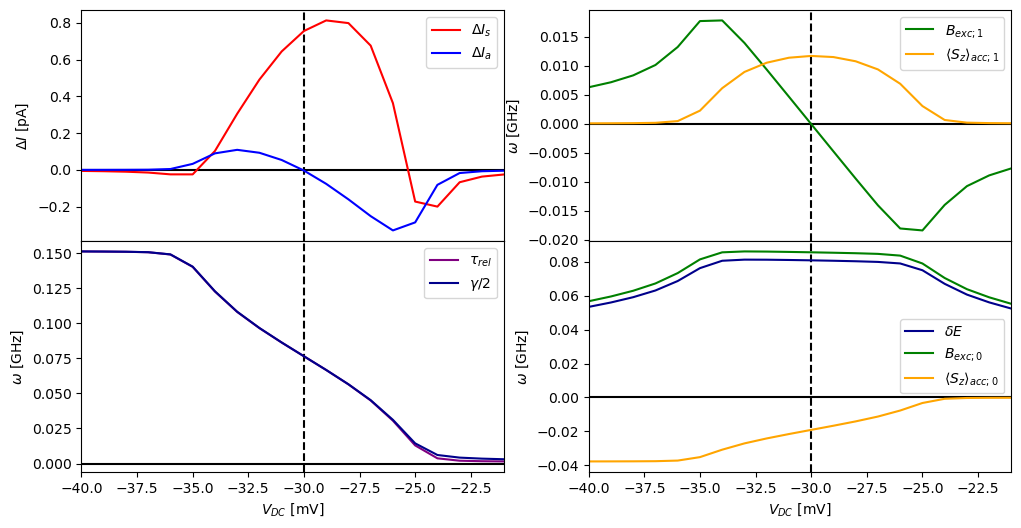

In [25]:
fig,ax = plt.subplots(2,2, figsize=(12,6), sharex=True)
ax= ax.flatten()
plt.subplots_adjust(hspace=0)

ax[3].plot(Vdcs, Lamb, 'darkblue', label=r'$\delta E$')
ax[3].plot(Vdcs, Lamb_pred, 'g', label=r'$B_{exc;0}$')
ax[3].plot(Vdcs, Sz0, 'orange', label=r'$\langle S_z \rangle_{acc;0}$')
ax[2].plot(Vdcs,  T1, 'purple', label=r'$\tau_{rel}$')
ax[2].plot(Vdcs, gamma/2, 'darkblue', label=r'$\gamma/2$')

ax[0].plot(Vdcs, Is, 'r', label=r'$\Delta I_s$')
ax[0].plot(Vdcs, Ia, 'b', label=r'$\Delta I_a$')
ax[1].plot(Vdcs, Bdrive, 'g', label=r'$B_{exc;1}$')
ax[1].plot(Vdcs, Sz1, 'orange', label=r'$\langle S_z \rangle_{acc;1}$')

for a in ax.flatten():
    a.set_xlim(-40, -21)
    xlim, ylim = a.get_xlim(), a.get_ylim()
    a.autoscale(False)

    #a.scatter([-35, -25], [0,0], c='black', marker='x', label=r'$\epsilon \pm V_{RF}$')
    a.hlines([0], xlim[0], xlim[1], 'k', '-', zorder=-1)
    a.vlines([-30], ylim[0], ylim[1], 'k', '--', zorder=-1)
    a.legend()

ax[2].set_ylabel(r'$\omega$ [GHz]')
ax[1].set_ylabel(r'$\omega$ [GHz]')
ax[3].set_ylabel(r'$\omega$ [GHz]')
ax[0].set_ylabel(r'$\Delta I$ [pA]')
ax[2].set_xlabel(r'$V_{DC}$ [mV]')
ax[3].set_xlabel(r'$V_{DC}$ [mV]')

fig.show()

## Refernces

[^Galvez2021]: Reina-Gálvez, J., Lorente, N., Delgado, F., & Arrachea, L. (2021). All-electric electron spin resonance studied by means of Floquet quantum master equations. Physical Review B, 104(24), 245435. https://doi.org/10.1103/PHYSREVB.104.245435

[^quspin]: Weinberg, P., & Bukov, M. (2017). QuSpin: A Python package for dynamics and exact diagonalisation of quantum many body systems Part I: Spin chains. SciPost Physics, 2(1), 003. https://doi.org/10.21468/SCIPOSTPHYS.2.1.003/PDF